In [1]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.legend_handler import HandlerLine2D

In [2]:
pd.options.display.float_format = '{:20,.2f}'.format

##### monthly csv as reference

In [ ]:
months = duckdb.sql("""
    SELECT distinct month AS months
    FROM ohsome
    WHERE month > '2019-12-01' AND n_changesets_AI != 0
    ORDER BY month
""").df()

In [ ]:
months['months'] = months['months'].str[:7]

In [ ]:
months.to_csv("statistical_evaluation/months.csv", index = False)

#### Set Up 

In [3]:
# the derived skill level of each contributor, both for their lifetime and adjusted to their monthly level
# extracted in 05_contributor_skill_wAI_ohsome_DATA
monthly_acc_wrld_20 = pd.read_csv(r"data\ouput\contributor_experience_9091_ohsome_monthly_adjsuted_20.csv")

In [4]:
months = pd.read_csv("statistical_evaluation/months.csv")

In [5]:
# contributor skill differentiated by their AI use
#changesets_level / edits_level  quivalent to n_changesets / n_edits in monthly_acc_wrld_20
combi = pd.read_csv(r"../data/ouput/contributor_experience_uid_ai_total_ohsome.csv")

In [6]:
combi

,user_id,month,n_changesets_AI,n_edits_AI,ai_only,contributor_type,changesets_level,edits_level
0,145231,2020-01-01,0.00,0.00,False,Prolific,5.00,31.00
1,300459,2020-01-01,0.00,0.00,False,Prolific,333.00,"96,734.00"
2,10927,2020-01-01,0.00,0.00,False,Prolific,39.00,"1,493.00"
3,402624,2020-01-01,0.00,0.00,False,Prolific,40.00,773.00
4,1679,2020-01-01,0.00,0.00,False,Prolific,511.00,"2,182.00"
...,...,...,...,...,...,...,...,...
3756930,24231849,2026-06-01,0.00,0.00,False,Inactive,1.00,1.00
3756931,24231868,2026-06-01,0.00,0.00,False,Inactive,1.00,1.00
3756932,24231874,2026-06-01,0.00,0.00,False,Inactive,1.00,1.00
3756933,24231902,2026-06-01,0.00,0.00,False,Inactive,1.00,1.00


In [10]:
# check
print(
    combi.groupby("contributor_type", observed=True)
    .agg(n_users=("user_id", "count"), total_edits=("n_edits_AI", "sum"))
    .assign(
        pct_users  = lambda d: (d.n_users      / d.n_users.sum()      * 100).round(2),
        pct_edits  = lambda d: (d.total_edits  / d.total_edits.sum()  * 100).round(2),
    )
)

                  n_users          total_edits            pct_users  \
contributor_type                                                      
Casual             688052        18,023,685.00                18.31   
Inactive          2691118         3,297,195.00                71.63   
Prolific           377765        70,859,006.00                10.06   

                            pct_edits  
contributor_type                       
Casual                          19.55  
Inactive                         3.58  
Prolific                        76.87  


In [7]:
# AI info with raw ohsome now resutl for data since 2020
merged_raw_20 = pd.read_csv(r"../data/ouput/raw_contributor_experience_uid_ai_total_country_ohsome.csv")

### Preparing For Plots

In [7]:
combi = combi.loc[combi["month"]<"2026-01-01"]

In [8]:
ai_only = combi.loc[combi["ai_only"]== True]

In [9]:
ai_only = ai_only.loc[ai_only["month"]<"2026-01-01"]

In [12]:
# check
print(
    ai_only.groupby("contributor_type", observed=True)
    .agg(n_users=("user_id", "count"), total_edits=("n_edits_AI", "sum"))
    .assign(
        pct_users  = lambda d: (d.n_users      / d.n_users.sum()      * 100).round(2),
        pct_edits  = lambda d: (d.total_edits  / d.total_edits.sum()  * 100).round(2),
    )
)

                  n_users          total_edits            pct_users  \
contributor_type                                                      
Casual               3765         4,747,344.00                17.12   
Inactive            14501         1,847,823.00                65.93   
Prolific             3727        19,119,715.00                16.95   

                            pct_edits  
contributor_type                       
Casual                          18.46  
Inactive                         7.19  
Prolific                        74.35  


In [11]:
# check
print(
    combi.groupby("contributor_type", observed=True)
    .agg(n_users=("user_id", "count"), total_edits=("n_edits_AI", "sum"))
    .assign(
        pct_users  = lambda d: (d.n_users      / d.n_users.sum()      * 100).round(2),
        pct_edits  = lambda d: (d.total_edits  / d.total_edits.sum()  * 100).round(2),
    )
)

                  n_users          total_edits            pct_users  \
contributor_type                                                      
Casual             632355        16,579,242.00                18.37   
Inactive          2462050         3,045,507.00                71.51   
Prolific           348468        63,809,571.00                10.12   

                            pct_edits  
contributor_type                       
Casual                          19.87  
Inactive                         3.65  
Prolific                        76.48  


In [15]:
combi_ai_only_contrib = combi.loc[combi["ai_only"]==True].copy()

In [16]:
combi['month'] = combi['month'].str[:7]
combi_ai_only_contrib['month'] = combi_ai_only_contrib['month'].str[:7]

In [17]:
monthly_ctypes_wrld = combi.pivot_table(
    index='month',
    columns='contributor_type',
    values='user_id',
    aggfunc='count'
).reset_index()

monthly_ctypes_wrld_ai = combi_ai_only_contrib.pivot_table(
    index='month',
    columns='contributor_type',
    values='user_id',
    aggfunc='count'
).reset_index().rename(columns={"Casual": "Casual AI", "Inactive": "Inactive AI", "Prolific":"Prolific AI"})

In [18]:
monthly_edits_wrld = combi.pivot_table(
    index='month',
    columns='contributor_type',
    values='edits_level',
    aggfunc='sum'
).reset_index()

monthly_changesets_wrld = combi.pivot_table(
    index='month',
    columns='contributor_type',
    values='changesets_level',
    aggfunc='sum'
).reset_index()

monthly_edits_wrld_ai = combi.pivot_table(
    index='month',
    columns='contributor_type',
    values='n_edits_AI',
    aggfunc='sum'
).reset_index().rename(columns={"Casual": "Casual AI", "Inactive": "Inactive AI", "Prolific":"Prolific AI"})

monthly_changesets_wrld_ai = combi.pivot_table(
    index='month',
    columns='contributor_type',
    values='n_changesets_AI',
    aggfunc='sum'
).reset_index().rename(columns={"Casual": "Casual AI", "Inactive": "Inactive AI", "Prolific":"Prolific AI"})

In [65]:
#monthly_changesets_wrld = monthly_changesets_wrld.merge(monthly_changesets_wrld_ai, on="month")
#monthly_edits_wrld = monthly_edits_wrld.merge(monthly_edits_wrld_ai, on="month")#
#monthly_ctypes_wrld = monthly_ctypes_wrld.merge(monthly_ctypes_wrld_ai, on="month")

### Plot

In [19]:
categories = ["Inactive", "Casual", "Prolific", "Inactive AI", "Casual AI", "Prolific AI"]
colors     = {"Inactive": "#63C132", "Casual": "#6A7FDB", "Prolific": "#E4572E",  "Inactive AI":"#63C132", "Casual AI" :"#6A7FDB", "Prolific AI":"#E4572E"}


In [20]:
def set_month_ticks(ax, months, mode="january", n=6, rotation=0):
    
    months = list(months)
    n_total = len(months)

    if mode == "january":
        major_idx = [i for i, m in enumerate(months) if m.endswith("-01")]
    else:
        major_idx = list(range(0, n_total, n))

    ax.set_xticks(major_idx)
    ax.set_xticklabels([months[i] for i in major_idx], rotation=rotation)
    ax.set_xticks(range(n_total), minor=True)  # unlabeled tick every month
    ax.tick_params(axis="x", which="minor", length=3, labelbottom=False)
    ax.tick_params(axis="x", which="major", length=6)

In [21]:
linewidth=4
def update(handle, orig):
    handle.update_from(orig)
    handle.set_linewidth(7)

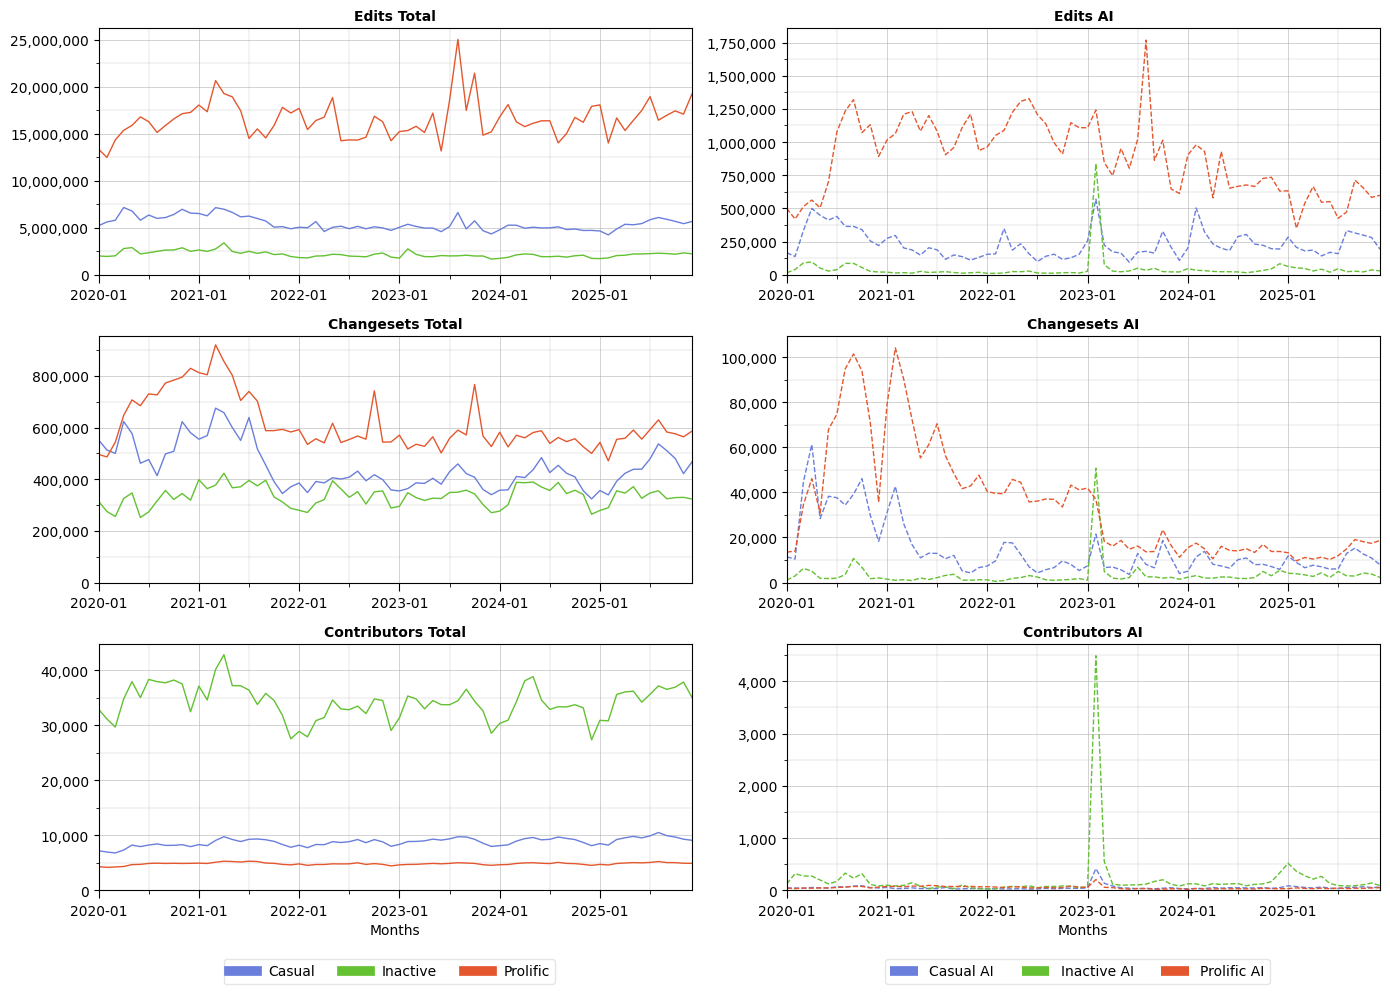

In [20]:
fig, ax = plt.subplots(3, 2, figsize=(14, 10))

ax1 = ax[0, 0]

ax1.set_title("Edits Total", fontsize=10, fontweight = "bold", loc='center')
monthly_edits_wrld.plot(
    x ="month",
    ax=ax1,
    linewidth=1,
    color=colors,
    legend=False
)
ax1.set_xlabel('')


ax2 = ax[1, 0]
ax2.set_title("Changesets Total", fontsize=10, fontweight = "bold", loc='center')
monthly_changesets_wrld.plot(
    x ="month",
    ax=ax2,
    linewidth=1,
    color=colors,
    legend=False
)
ax2.set_xlabel('')

ax3 = ax[2, 0]
ax3.set_title("Contributors Total", fontsize=10, fontweight = "bold", loc='center')
monthly_ctypes_wrld.plot(
    x ="month",
    ax=ax3,
    linewidth=1,
    color=colors,
    #legend=False
)
ax3.set_xlabel('Months')
ax3.legend(loc="upper center",  ncols=3, frameon=True, facecolor="w", framealpha = 0.5, bbox_to_anchor=(0.49, -0.25),
          handler_map={plt.Line2D : HandlerLine2D(update_func=update)})


# AI only measures
ax4 = ax[0, 1]
ax4.set_title("Edits AI", fontsize=10, fontweight = "bold", loc='center')
monthly_edits_wrld_ai.plot(
    x ="month",
    ax=ax4,
    linewidth=1,
    color=colors, 
    legend=False,
    linestyle='dashed',
)
ax4.set_xlabel('')


ax5 = ax[1, 1]
ax5.set_title("Changesets AI", fontsize=10, fontweight = "bold", loc='center')
monthly_changesets_wrld_ai.plot(
    x ="month",
    ax=ax5,
    linewidth=1,
    color=colors,
    legend=False,
    linestyle='dashed'
)
ax5.set_xlabel('')

ax6 = ax[2, 1]
ax6.set_title("Contributors AI", fontsize=10, fontweight = "bold", loc='center')
monthly_ctypes_wrld_ai.plot(
    x ="month",
    ax=ax6,
    linewidth=1,
    color=colors,
    #legend=False,
    linestyle='dashed'
)
ax6.set_xlabel('Months')

ax6.legend(loc="upper center", ncols=3, frameon=True, facecolor="w", framealpha = 0.5, bbox_to_anchor=(0.49, -0.25), 
          handler_map={plt.Line2D : HandlerLine2D(update_func=update)})

dfs = {
    ax1: monthly_edits_wrld,       ax2: monthly_changesets_wrld,  ax3: monthly_ctypes_wrld,
    ax4: monthly_edits_wrld_ai,    ax5: monthly_changesets_wrld_ai, ax6: monthly_ctypes_wrld_ai,
}
for a, df in dfs.items():
    set_month_ticks(a, df["month"], mode="january")   # or mode="every_n", n=6
    a.set_xlim(0, len(df) - 1)   # replaces your hardcoded len(monthly_edits_wrld)-1

for a in ax.flat:
   # a.grid(linewidth=0.2, color="gray")
    a.yaxis.set_minor_locator(AutoMinorLocator(2))  
    a.xaxis.set_minor_locator(AutoMinorLocator(2))
    a.grid(which='major', linewidth=0.4)
    a.grid(which='minor', linewidth=0.2, )  
    a.set_ylim(0,)
    a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    a.set_xlim(0, len(monthly_edits_wrld) - 1)


plt.tight_layout()
plt.savefig("../results/monthly_contribs_skill_level_ohsome_AI_update_v2.png", dpi=150)
plt.show()

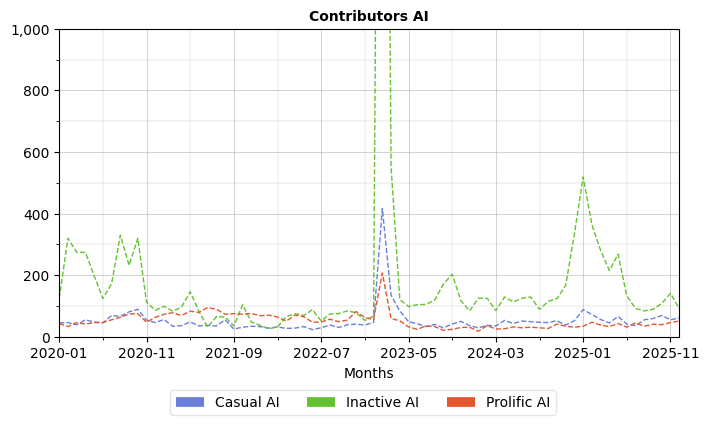

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.set_title("Contributors AI", fontsize=10, fontweight = "bold", loc='center')
monthly_ctypes_wrld_ai.plot(
    x ="month",
    ax=ax,
    linewidth=1,
    color=colors,
    #legend=False,
    linestyle='dashed'
)
ax.set_xlabel('Months')
ax.set_ylim(0,1000
           )
ax.legend(loc="upper center", ncols=3, frameon=True, facecolor="w", framealpha = 0.5, bbox_to_anchor=(0.49, -0.15), 
          handler_map={plt.Line2D : HandlerLine2D(update_func=update)})
ax.yaxis.set_minor_locator(AutoMinorLocator(2))  
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(which='major', linewidth=0.4)
ax.grid(which='minor', linewidth=0.2, )  
ax.set_ylim(0,)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_xlim(0, len(monthly_edits_wrld) - 1)
plt.savefig("../results/monthly_contribs_skill_level_contributorsAI_view.png", dpi=300)

plt.show()